# AG News Topic Classification with Three Models



In [ ]:
# CELL 2 — Install the libraries required in Google Colab.
# Colab already includes PyTorch, NumPy, pandas and scikit-learn, but this
# command ensures that a recent Hugging Face Transformers version is available.

%pip -q install -U "transformers>=4.40,<5" accelerate scikit-learn pandas matplotlib tqdm joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pand

In [ ]:
# CELL 3 — Imports, reproducibility settings and experiment configuration.

import gc
import json
import os
import random
import re
import shutil
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from torch.nn.utils import clip_grad_norm_
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
VALIDATION_SIZE = 0.10

# AG News articles are usually short. The tokenizer analysis later measures
# how many examples would be truncated at this length.
MAX_LENGTH = 160

# Hyperparameter searches use stratified subsets to keep Colab runtime
# practical. After selection, each final model is fitted on the full training
# split unless RUN_FULL_FINAL_TRAINING is changed to False.
BASELINE_TUNING_ROWS = 60_000
TRANSFORMER_TUNING_TRAIN_ROWS = 24_000
TRANSFORMER_TUNING_VAL_ROWS = 6_000
TUNING_EPOCHS = 1
FINAL_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 2
RUN_FULL_FINAL_TRAINING = True
REDUCED_FINAL_TRAIN_ROWS = 48_000

NUM_WORKERS = 2
MODEL_CHECKPOINT = "distilbert-base-uncased"

CLASS_ID_TO_NAME = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
}
CLASS_NAME_TO_ID = {name: idx for idx, name in CLASS_ID_TO_NAME.items()}
CLASS_NAMES = [CLASS_ID_TO_NAME[i] for i in range(len(CLASS_ID_TO_NAME))]
NUM_LABELS = len(CLASS_NAMES)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

def set_seed(seed: int = SEED) -> None:
    """Set Python, NumPy and PyTorch seeds for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)
print("Automatic mixed precision enabled:", AMP_ENABLED)

PyTorch version: 2.11.0+cu128
Device: cuda
Automatic mixed precision enabled: True


In [ ]:
# CELL 4 — Mount Google Drive and locate the AG News CSV files.

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")
PREFERRED_DATA_DIR = DRIVE_ROOT / "AG_News_Dataset"
DRIVE_OUTPUT_DIR = DRIVE_ROOT / "ag_news_llm_outputs"
LOCAL_DATA_DIR = Path("/content/ag_news_data")
LOCAL_OUTPUT_DIR = Path("/content/ag_news_llm_outputs")

EXPECTED_COLUMNS = {"Class Index", "Title", "Description"}

def has_expected_schema(csv_path: Path) -> bool:
    """Read only the header and confirm that the required columns exist."""
    try:
        header = pd.read_csv(csv_path, nrows=3)
        return EXPECTED_COLUMNS.issubset(header.columns)
    except Exception:
        return False

def locate_dataset_pair() -> tuple[Path, Path]:
    """Return a validated train.csv/test.csv pair from Google Drive."""
    preferred_train = PREFERRED_DATA_DIR / "train.csv"
    preferred_test = PREFERRED_DATA_DIR / "test.csv"

    if (
        preferred_train.exists()
        and preferred_test.exists()
        and has_expected_schema(preferred_train)
        and has_expected_schema(preferred_test)
    ):
        return preferred_train, preferred_test

    valid_pairs = []
    for candidate_train in DRIVE_ROOT.rglob("train.csv"):
        candidate_test = candidate_train.parent / "test.csv"
        if (
            candidate_test.exists()
            and has_expected_schema(candidate_train)
            and has_expected_schema(candidate_test)
        ):
            valid_pairs.append((candidate_train, candidate_test))

    if not valid_pairs:
        raise FileNotFoundError(
            "No valid AG News train.csv/test.csv pair was found. "
            "Place both files in MyDrive/AG_News_Dataset and run this cell again."
        )

    if len(valid_pairs) > 1:
        print("Multiple valid pairs were found. The first one will be used:")
        for train_path, test_path in valid_pairs:
            print(" -", train_path.parent)

    return sorted(valid_pairs, key=lambda pair: str(pair[0]))[0]

drive_train_path, drive_test_path = locate_dataset_pair()

# Copy once to Colab's local disk. Training reads local files more quickly,
# while all final artefacts are still saved back to Google Drive.
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

local_train_path = LOCAL_DATA_DIR / "train.csv"
local_test_path = LOCAL_DATA_DIR / "test.csv"
shutil.copy2(drive_train_path, local_train_path)
shutil.copy2(drive_test_path, local_test_path)

print("Training file:", drive_train_path)
print("Test file:    ", drive_test_path)
print("Output folder:", DRIVE_OUTPUT_DIR)

Mounted at /content/drive
Training file: /content/drive/MyDrive/train.csv
Test file:     /content/drive/MyDrive/test.csv
Output folder: /content/drive/MyDrive/ag_news_llm_outputs


In [ ]:
# CELL 5 — Load and validate the dataset before modelling.

raw_train_df = pd.read_csv(local_train_path)
raw_test_df = pd.read_csv(local_test_path)

def validate_ag_news_frame(frame: pd.DataFrame, frame_name: str) -> None:
    """Fail early when the file does not match the expected AG News structure."""
    missing_columns = EXPECTED_COLUMNS.difference(frame.columns)
    if missing_columns:
        raise ValueError(f"{frame_name} is missing columns: {sorted(missing_columns)}")

    observed_classes = set(frame["Class Index"].dropna().astype(int).unique())
    expected_classes = {1, 2, 3, 4}
    if observed_classes != expected_classes:
        raise ValueError(
            f"{frame_name} class values are {sorted(observed_classes)}, "
            f"but AG News should contain {sorted(expected_classes)}."
        )

validate_ag_news_frame(raw_train_df, "train.csv")
validate_ag_news_frame(raw_test_df, "test.csv")

dataset_profile = pd.DataFrame(
    {
        "split": ["Raw train", "Official test"],
        "rows": [len(raw_train_df), len(raw_test_df)],
        "columns": [raw_train_df.shape[1], raw_test_df.shape[1]],
        "missing_values": [
            int(raw_train_df.isna().sum().sum()),
            int(raw_test_df.isna().sum().sum()),
        ],
        "exact_duplicate_rows": [
            int(raw_train_df.duplicated().sum()),
            int(raw_test_df.duplicated().sum()),
        ],
    }
)

display(dataset_profile)
display(raw_train_df.head())
print("\nRaw training class counts:")
display(raw_train_df["Class Index"].value_counts().sort_index().rename(index={
    1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"
}).to_frame("count"))

,split,rows,columns,missing_values,exact_duplicate_rows
0,Raw train,120000,3,0,0
1,Official test,7600,3,0,0


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."



Raw training class counts:


,count
Class Index,
World,30000
Sports,30000
Business,30000
Sci/Tech,30000


In [ ]:
# CELL 6 — Text normalisation, duplicate/leakage checks and stratified split.
#
# Cleaning is deliberately conservative. It normalises whitespace but keeps
# punctuation and wording because those features can be useful to both TF-IDF
# and DistilBERT.

def normalise_text(value: object) -> str:
    """Convert text to string, remove control whitespace and collapse spaces."""
    text = "" if pd.isna(value) else str(value)
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def prepare_frame(frame: pd.DataFrame) -> pd.DataFrame:
    """Create clean fields, combined baseline text and zero-based labels."""
    prepared = frame.copy()
    prepared["Title"] = prepared["Title"].map(normalise_text)
    prepared["Description"] = prepared["Description"].map(normalise_text)
    prepared["text"] = (
        "TITLE: " + prepared["Title"] + " DESCRIPTION: " + prepared["Description"]
    )
    prepared["label"] = prepared["Class Index"].astype(int) - 1
    prepared["label_name"] = prepared["label"].map(CLASS_ID_TO_NAME)
    return prepared

full_train_df = prepare_frame(raw_train_df)
test_df = prepare_frame(raw_test_df)

empty_train_mask = (
    full_train_df["Title"].eq("") & full_train_df["Description"].eq("")
)
empty_test_mask = test_df["Title"].eq("") & test_df["Description"].eq("")
print("Empty training records:", int(empty_train_mask.sum()))
print("Empty test records:    ", int(empty_test_mask.sum()))
full_train_df = full_train_df.loc[~empty_train_mask].copy()
test_df = test_df.loc[~empty_test_mask].copy()

# Remove every duplicated training text, rather than arbitrarily keeping one,
# because some duplicated texts can carry conflicting labels.
duplicated_train_text = full_train_df.duplicated("text", keep=False)
conflicting_duplicate_groups = (
    full_train_df.loc[duplicated_train_text]
    .groupby("text")["label"]
    .nunique()
    .gt(1)
    .sum()
)
print("Training rows belonging to duplicated-text groups:", int(duplicated_train_text.sum()))
print("Duplicated-text groups with conflicting labels:   ", int(conflicting_duplicate_groups))
full_train_df = full_train_df.loc[~duplicated_train_text].copy()

# Protect the official test set from exact text leakage.
test_text_set = set(test_df["text"])
train_test_overlap = full_train_df["text"].isin(test_text_set)
print("Exact train/test text overlaps removed from training:", int(train_test_overlap.sum()))
full_train_df = full_train_df.loc[~train_test_overlap].reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df, val_df = train_test_split(
    full_train_df,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=full_train_df["label"],
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

split_summary = pd.DataFrame(
    {
        "split": ["Train", "Validation", "Official test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
    }
)
display(split_summary)

class_balance = pd.concat(
    {
        "Train": train_df["label_name"].value_counts(normalize=True),
        "Validation": val_df["label_name"].value_counts(normalize=True),
        "Test": test_df["label_name"].value_counts(normalize=True),
    },
    axis=1,
).reindex(CLASS_NAMES)

display((class_balance * 100).round(2).rename_axis("class").add_suffix(" (%)"))

Empty training records: 0
Empty test records:     0
Training rows belonging to duplicated-text groups: 158
Duplicated-text groups with conflicting labels:    15
Exact train/test text overlaps removed from training: 4


,split,rows
0,Train,107854
1,Validation,11984
2,Official test,7600


,Train (%),Validation (%),Test (%)
class,,,
World,25.01,25.02,25.0
Sports,25.01,25.01,25.0
Business,24.99,24.99,25.0
Sci/Tech,24.99,24.98,25.0


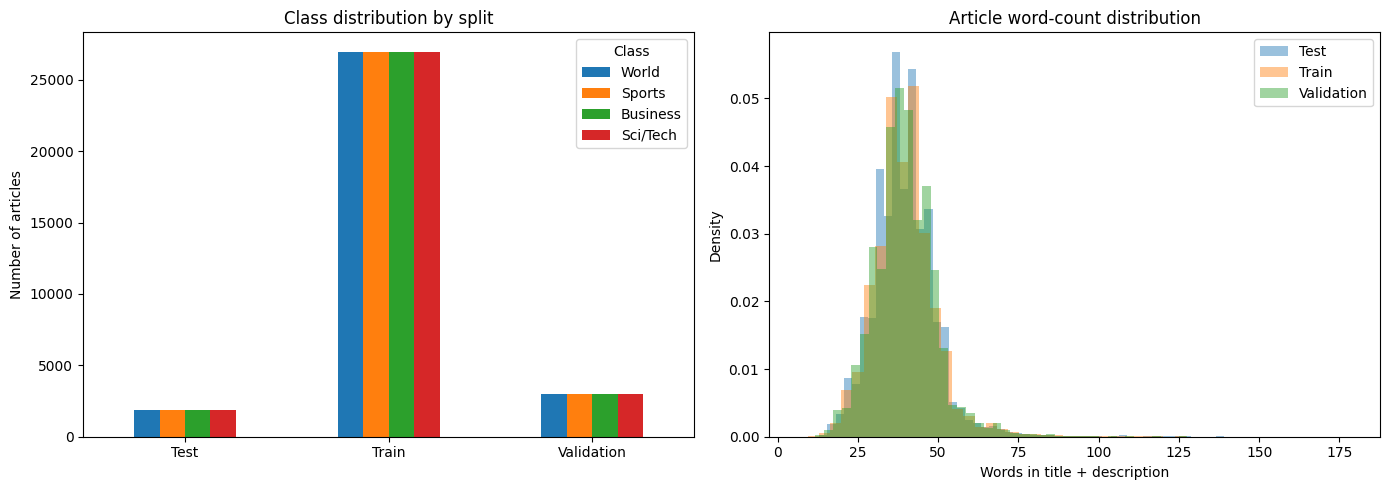

word_count                                               \
                count   mean    std   min   25%   50%   75%    max   
split                                                                
Test           7600.0  39.72  10.13  13.0  34.0  39.0  45.0  139.0   
Train        107854.0  39.85  10.11   6.0  34.0  39.0  45.0  179.0   
Validation    11984.0  39.82   9.95   9.0  34.0  39.0  45.0  147.0   

           character_count                                                     
                     count    mean    std    min    25%    50%    75%     max  
split                                                                          
Test                7600.0  254.73  64.85  120.0  216.0  251.0  285.0   900.0  
Train             107854.0  255.91  66.12   37.0  216.0  251.0  286.0  1032.0  
Validation         11984.0  255.66  65.65   63.0  216.0  251.0  285.0   977.0

,label_name,Title,Description
21669,Business,Regulator agrees power price rise,Power network distribution charges are to rise...
33380,Sci/Tech,NASA calls off launch of black hole-hunter,"CAPE CANAVERAL, Fla. -- With just hours left i..."
91517,Sports,US eliminated in Champions Trophy,"SOUTHAMPTON, England - The US cricket team is ..."
76720,World,Investigation underway into Indonesian plane c...,Indonesian transport safety officials have lau...


In [ ]:
# CELL 7 — Exploratory data analysis.
#
# These figures document class balance and article length, while the examples
# help verify that the class mapping is semantically correct.

eda_df = pd.concat(
    [
        train_df.assign(split="Train"),
        val_df.assign(split="Validation"),
        test_df.assign(split="Test"),
    ],
    ignore_index=True,
)

eda_df["word_count"] = eda_df["text"].str.split().str.len()
eda_df["character_count"] = eda_df["text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = (
    eda_df.groupby(["split", "label_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_NAMES)
)
class_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Class distribution by split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of articles")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Class")

for split_name, group in eda_df.groupby("split"):
    axes[1].hist(
        group["word_count"],
        bins=50,
        alpha=0.45,
        label=split_name,
        density=True,
    )
axes[1].set_title("Article word-count distribution")
axes[1].set_xlabel("Words in title + description")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

length_summary = (
    eda_df.groupby("split")[["word_count", "character_count"]]
    .describe()
    .round(2)
)
display(length_summary)

example_rows = (
    train_df.groupby("label_name", group_keys=False)
    .sample(n=1, random_state=SEED)
    [["label_name", "Title", "Description"]]
    .sort_values("label_name")
)
display(example_rows)

In [ ]:
# CELL 8 — Shared evaluation and sampling utilities.
#
# Macro averaging gives every topic equal importance. This is appropriate even
# though AG News is balanced, and it remains robust if future data are not.

def calculate_metrics(y_true, y_pred) -> dict:
    """Return the four principal assignment metrics plus weighted F1."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }

def show_classification_results(model_name, y_true, y_pred) -> pd.DataFrame:
    """Print headline metrics and return a class-level classification report."""
    metrics = calculate_metrics(y_true, y_pred)
    print(f"\n{model_name}")
    print("-" * len(model_name))
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name:>18}: {metric_value:.4f}")

    report = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            labels=list(range(NUM_LABELS)),
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()
    display(report.round(4))
    return report

def stratified_sample_frame(
    frame: pd.DataFrame,
    requested_rows: int | None,
    seed: int = SEED,
) -> pd.DataFrame:
    """Return a reproducible stratified sample, or the full frame when small."""
    if requested_rows is None or requested_rows >= len(frame):
        return frame.copy().reset_index(drop=True)

    sampled, _ = train_test_split(
        frame,
        train_size=requested_rows,
        random_state=seed,
        stratify=frame["label"],
    )
    return sampled.reset_index(drop=True)

def stratified_indices(
    labels,
    requested_rows: int | None,
    seed: int = SEED,
) -> np.ndarray:
    """Return indices for a stratified PyTorch Subset."""
    labels = np.asarray(labels)
    all_indices = np.arange(len(labels))

    if requested_rows is None or requested_rows >= len(labels):
        return all_indices

    selected, _ = train_test_split(
        all_indices,
        train_size=requested_rows,
        random_state=seed,
        stratify=labels,
    )
    return np.asarray(selected)

baseline_tuning_df = stratified_sample_frame(
    train_df,
    BASELINE_TUNING_ROWS,
    seed=SEED,
)

print("Rows used for classical-model hyperparameter search:", len(baseline_tuning_df))

model_results = {}
prediction_store = {}
classification_reports = {}

Rows used for classical-model hyperparameter search: 60000


In [ ]:
# CELL 9 — Model 1: TF-IDF + Multinomial Naive Bayes.
#
# Hyperparameters:
# - word n-gram range controls local phrase information;
# - alpha controls additive smoothing;
# - min_df removes extremely rare terms.
#
# The grid is selected by 3-fold cross-validated macro F1 on the training-only
# tuning subset. The selected pipeline is then refitted on the full train split.

nb_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                sublinear_tf=True,
                max_df=0.98,
                max_features=60_000,
            ),
        ),
        ("classifier", MultinomialNB()),
    ]
)

nb_parameter_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 5],
    "classifier__alpha": [0.1, 0.5, 1.0],
}

nb_search = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_parameter_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

nb_search.fit(baseline_tuning_df["text"], baseline_tuning_df["label"])

print("Best Naive Bayes parameters:", nb_search.best_params_)
print("Best cross-validation macro F1:", round(nb_search.best_score_, 4))

nb_cv_results = (
    pd.DataFrame(nb_search.cv_results_)
    .sort_values("rank_test_score")
    [[
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "param_tfidf__ngram_range",
        "param_tfidf__min_df",
        "param_classifier__alpha",
    ]]
)
display(nb_cv_results.head(10).round(4))

nb_model = clone(nb_pipeline).set_params(**nb_search.best_params_)
nb_model.fit(train_df["text"], train_df["label"])

nb_val_pred = nb_model.predict(val_df["text"])
nb_test_pred = nb_model.predict(test_df["text"])
nb_test_prob = nb_model.predict_proba(test_df["text"])

nb_val_metrics = calculate_metrics(val_df["label"], nb_val_pred)
nb_test_metrics = calculate_metrics(test_df["label"], nb_test_pred)

classification_reports["TF-IDF + Multinomial NB"] = show_classification_results(
    "TF-IDF + Multinomial NB — official test",
    test_df["label"],
    nb_test_pred,
)

model_results["TF-IDF + Multinomial NB"] = {
    "system_type": "Baseline",
    "validation": nb_val_metrics,
    "test": nb_test_metrics,
    "best_parameters": nb_search.best_params_,
}
prediction_store["TF-IDF + Multinomial NB"] = {
    "predictions": nb_test_pred,
    "probabilities": nb_test_prob,
}

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Naive Bayes parameters: {'classifier__alpha': 0.1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best cross-validation macro F1: 0.9025


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_tfidf__ngram_range,param_tfidf__min_df,param_classifier__alpha
1,1,0.9025,0.0005,0.9344,"(1, 2)",2,0.1
3,2,0.9021,0.0009,0.9341,"(1, 2)",5,0.1
0,3,0.9008,0.0013,0.9304,"(1, 1)",2,0.1
5,4,0.9005,0.0008,0.9249,"(1, 2)",2,0.5
7,5,0.8999,0.0009,0.9245,"(1, 2)",5,0.5
4,6,0.8998,0.0012,0.9212,"(1, 1)",2,0.5
9,7,0.8993,0.0010,0.9201,"(1, 2)",2,1.0
11,8,0.8987,0.0011,0.9199,"(1, 2)",5,1.0
8,9,0.8985,0.0014,0.9168,"(1, 1)",2,1.0
2,10,0.8983,0.0013,0.9211,"(1, 1)",5,0.1



TF-IDF + Multinomial NB — official test
---------------------------------------
          accuracy: 0.9034
   precision_macro: 0.9034
      recall_macro: 0.9034
          f1_macro: 0.9031
       f1_weighted: 0.9031


,precision,recall,f1-score,support
World,0.9205,0.8900,0.9050,1900.0000
Sports,0.9486,0.9805,0.9643,1900.0000
Business,0.8819,0.8453,0.8632,1900.0000
Sci/Tech,0.8625,0.8979,0.8798,1900.0000
accuracy,0.9034,0.9034,0.9034,0.9034
macro avg,0.9034,0.9034,0.9031,7600.0000
weighted avg,0.9034,0.9034,0.9031,7600.0000


In [ ]:
# CELL 10 — Model 2: TF-IDF + Logistic Regression.
#
# Logistic Regression is a strong discriminative text baseline. The grid tunes
# the n-gram range, minimum document frequency and inverse regularisation
# strength C. A larger C means weaker regularisation.

lr_pipeline = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                sublinear_tf=True,
                max_df=0.98,
                max_features=60_000,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                solver="saga",
                max_iter=700,
                tol=1e-3,
                random_state=SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

lr_parameter_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 5],
    "classifier__C": [0.5, 1.0, 2.0],
}

lr_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_parameter_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

lr_search.fit(baseline_tuning_df["text"], baseline_tuning_df["label"])

print("Best Logistic Regression parameters:", lr_search.best_params_)
print("Best cross-validation macro F1:", round(lr_search.best_score_, 4))

lr_cv_results = (
    pd.DataFrame(lr_search.cv_results_)
    .sort_values("rank_test_score")
    [[
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "param_tfidf__ngram_range",
        "param_tfidf__min_df",
        "param_classifier__C",
    ]]
)
display(lr_cv_results.head(10).round(4))

lr_model = clone(lr_pipeline).set_params(**lr_search.best_params_)
lr_model.fit(train_df["text"], train_df["label"])

lr_val_pred = lr_model.predict(val_df["text"])
lr_test_pred = lr_model.predict(test_df["text"])
lr_test_prob = lr_model.predict_proba(test_df["text"])

lr_val_metrics = calculate_metrics(val_df["label"], lr_val_pred)
lr_test_metrics = calculate_metrics(test_df["label"], lr_test_pred)

classification_reports["TF-IDF + Logistic Regression"] = show_classification_results(
    "TF-IDF + Logistic Regression — official test",
    test_df["label"],
    lr_test_pred,
)

model_results["TF-IDF + Logistic Regression"] = {
    "system_type": "Baseline",
    "validation": lr_val_metrics,
    "test": lr_test_metrics,
    "best_parameters": lr_search.best_params_,
}
prediction_store["TF-IDF + Logistic Regression"] = {
    "predictions": lr_test_pred,
    "probabilities": lr_test_prob,
}

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Logistic Regression parameters: {'classifier__C': 2.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best cross-validation macro F1: 0.9101


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_tfidf__ngram_range,param_tfidf__min_df,param_classifier__C
9,1,0.9101,0.0006,0.9688,"(1, 2)",2,2.0
11,2,0.9099,0.0005,0.9686,"(1, 2)",5,2.0
5,3,0.9085,0.0006,0.9521,"(1, 2)",2,1.0
7,4,0.9082,0.0006,0.9520,"(1, 2)",5,1.0
8,5,0.9080,0.0011,0.9577,"(1, 1)",2,2.0
10,6,0.9075,0.0010,0.9543,"(1, 1)",5,2.0
4,7,0.9072,0.0010,0.9439,"(1, 1)",2,1.0
6,8,0.9068,0.0011,0.9412,"(1, 1)",5,1.0
1,9,0.9041,0.0008,0.9367,"(1, 2)",2,0.5
3,10,0.9039,0.0009,0.9365,"(1, 2)",5,0.5



TF-IDF + Logistic Regression — official test
--------------------------------------------
          accuracy: 0.9232
   precision_macro: 0.9231
      recall_macro: 0.9232
          f1_macro: 0.9230
       f1_weighted: 0.9230


,precision,recall,f1-score,support
World,0.9372,0.9116,0.9242,1900.0000
Sports,0.9573,0.9795,0.9683,1900.0000
Business,0.8955,0.8932,0.8943,1900.0000
Sci/Tech,0.9022,0.9084,0.9053,1900.0000
accuracy,0.9232,0.9232,0.9232,0.9232
macro avg,0.9231,0.9232,0.9230,7600.0000
weighted avg,0.9231,0.9232,0.9230,7600.0000


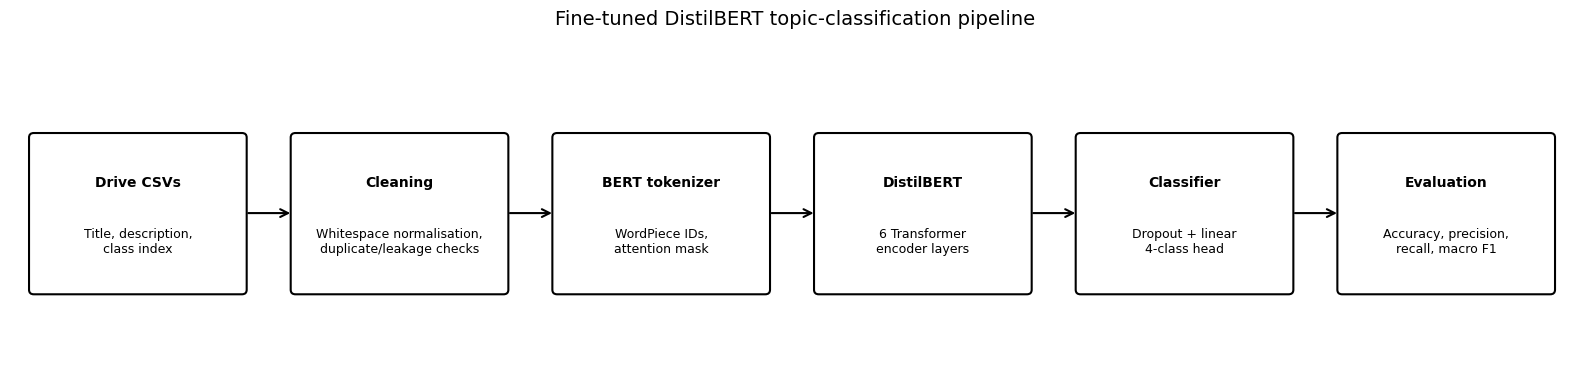

Why the architecture suits this task:
• Bidirectional self-attention models context across the complete news text.
• Pre-training transfers general language knowledge to a supervised dataset.
• Fine-tuning updates the encoder and classification head for the four AG News topics.
• Distillation reduces computation compared with full BERT, which is practical in Colab.


In [ ]:
# CELL 11 — DistilBERT architecture and end-to-end pipeline diagram.
#
# DistilBERT retains BERT's bidirectional Transformer encoder and WordPiece
# tokenisation while reducing the number of encoder layers. The classification
# head converts the contextual representation into four class logits.

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

pipeline_stages = [
    ("Drive CSVs", "Title, description,\nclass index"),
    ("Cleaning", "Whitespace normalisation,\nduplicate/leakage checks"),
    ("BERT tokenizer", "WordPiece IDs,\nattention mask"),
    ("DistilBERT", "6 Transformer\nencoder layers"),
    ("Classifier", "Dropout + linear\n4-class head"),
    ("Evaluation", "Accuracy, precision,\nrecall, macro F1"),
]

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, len(pipeline_stages) * 2.2)
ax.set_ylim(0, 3)
ax.axis("off")

for index, (title, detail) in enumerate(pipeline_stages):
    x = index * 2.2 + 0.2
    box = FancyBboxPatch((x, 0.8),1.75,1.35,boxstyle="round,pad=0.04",linewidth=1.5,facecolor="white",)
    ax.add_patch(box)
    ax.text(x + 0.875, 1.75, title, ha="center", va="center", fontweight="bold")
    ax.text(x + 0.875, 1.22, detail, ha="center", va="center", fontsize=9)

    if index < len(pipeline_stages) - 1:
        arrow = FancyArrowPatch((x + 1.78, 1.48),(x + 2.18, 1.48),arrowstyle="->",mutation_scale=14,linewidth=1.5,)
        ax.add_patch(arrow)

ax.set_title("Fine-tuned DistilBERT topic-classification pipeline", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

print(
    "Why the architecture suits this task:\n"
    "• Bidirectional self-attention models context across the complete news text.\n"
    "• Pre-training transfers general language knowledge to a supervised dataset.\n"
    "• Fine-tuning updates the encoder and classification head for the four AG News topics.\n"
    "• Distillation reduces computation compared with full BERT, which is practical in Colab."
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: DistilBertTokenizerFast
Sample size: 10000
Median token length: 52
95th percentile: 83
Maximum token length: 353
Estimated truncation rate at MAX_LENGTH=160: 0.43%


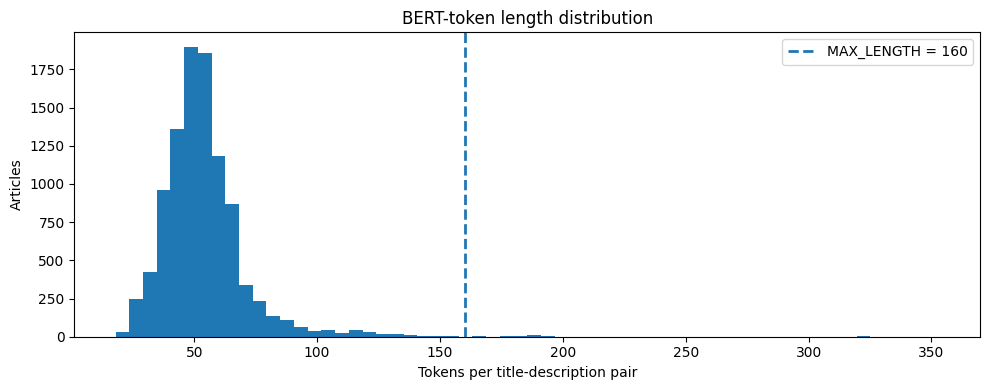

The selected maximum length preserves most articles while limiting padding and GPU memory use.


In [ ]:
# CELL 12 — Load the BERT-style tokenizer and quantify truncation.
#
# Titles and descriptions are supplied as a sentence pair. The tokenizer inserts
# its own special tokens and keeps the two fields structurally separate.

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, use_fast=True)

token_length_sample = stratified_sample_frame(
    train_df,
    requested_rows=min(10_000, len(train_df)),
    seed=SEED,
)

sample_encodings = tokenizer(
    token_length_sample["Title"].tolist(),
    token_length_sample["Description"].tolist(),
    truncation=False,
    padding=False,
)

token_lengths = np.asarray([len(ids) for ids in sample_encodings["input_ids"]])
truncation_rate = float(np.mean(token_lengths > MAX_LENGTH))

print("Tokenizer:", tokenizer.__class__.__name__)
print("Sample size:", len(token_lengths))
print("Median token length:", int(np.median(token_lengths)))
print("95th percentile:", int(np.percentile(token_lengths, 95)))
print("Maximum token length:", int(token_lengths.max()))
print(f"Estimated truncation rate at MAX_LENGTH={MAX_LENGTH}: {truncation_rate:.2%}")

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=60)
plt.axvline(MAX_LENGTH, linestyle="--", linewidth=2, label=f"MAX_LENGTH = {MAX_LENGTH}")
plt.title("BERT-token length distribution")
plt.xlabel("Tokens per title-description pair")
plt.ylabel("Articles")
plt.legend()
plt.tight_layout()
plt.show()

if truncation_rate > 0.05:
    print(
        "Warning: more than 5% of the sample would be truncated. "
        "Increase MAX_LENGTH if GPU memory permits."
    )
else:
    print(
        "The selected maximum length preserves most articles while limiting "
        "padding and GPU memory use."
    )

In [ ]:
# CELL 13 — PyTorch Dataset, dynamic-padding collator and DataLoader helpers.
#
# The dataset is tokenised once with the fast tokenizer. Padding is performed
# dynamically per batch, so short articles do not consume a fixed MAX_LENGTH
# allocation unnecessarily.

class EncodedNewsDataset(Dataset):
    """Tokenised title-description pairs with integer class labels."""

    def __init__(
        self,
        frame: pd.DataFrame,
        tokenizer,
        max_length: int,
    ) -> None:
        self.encodings = tokenizer(
            frame["Title"].tolist(),
            frame["Description"].tolist(),
            truncation=True,
            max_length=max_length,
            padding=False,
        )
        self.labels = frame["label"].astype(int).tolist()

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> dict:
        item = {
            key: value[index]
            for key, value in self.encodings.items()
        }
        item["labels"] = self.labels[index]
        return item


class DynamicPaddingCollator:
    """Pad each batch to its longest sequence and create a label tensor."""

    def __init__(self, tokenizer) -> None:
        self.tokenizer = tokenizer

    def __call__(self, features: list[dict]) -> dict:
        features = [dict(feature) for feature in features]
        labels = torch.tensor(
            [feature.pop("labels") for feature in features],
            dtype=torch.long,
        )
        batch = self.tokenizer.pad(
            features,
            padding=True,
            return_tensors="pt",
        )
        batch["labels"] = labels
        return batch


def make_loader(
    dataset,
    batch_size: int,
    shuffle: bool,
) -> DataLoader:
    """Build a reproducible DataLoader with dynamic padding."""
    generator = torch.Generator()
    generator.manual_seed(SEED)

    loader_kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": shuffle,
        "collate_fn": DynamicPaddingCollator(tokenizer),
        "num_workers": NUM_WORKERS,
        "pin_memory": DEVICE.type == "cuda",
        "generator": generator,
    }
    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True

    return DataLoader(**loader_kwargs)


print("Tokenising the train, validation and test splits...")
train_dataset = EncodedNewsDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset = EncodedNewsDataset(val_df, tokenizer, MAX_LENGTH)
test_dataset = EncodedNewsDataset(test_df, tokenizer, MAX_LENGTH)

print("Encoded train examples:", len(train_dataset))
print("Encoded validation examples:", len(val_dataset))
print("Encoded test examples:", len(test_dataset))

Tokenising the train, validation and test splits...
Encoded train examples: 107854
Encoded validation examples: 11984
Encoded test examples: 7600


In [ ]:
# CELL 14 — DistilBERT construction, explicit loss, training and evaluation loops.

def build_distilbert(classifier_dropout: float) -> nn.Module:
    """Load DistilBERT with a new four-class classification head."""
    config = AutoConfig.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=NUM_LABELS,
        id2label=CLASS_ID_TO_NAME,
        label2id=CLASS_NAME_TO_ID,
    )

    if hasattr(config, "seq_classif_dropout"):
        config.seq_classif_dropout = classifier_dropout
    if hasattr(config, "classifier_dropout"):
        config.classifier_dropout = classifier_dropout

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        config=config,
    )
    return model.to(DEVICE)


def create_grad_scaler():
    """Create an AMP scaler while retaining compatibility with PyTorch releases."""
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


def autocast_context():
    """Return the correct automatic-mixed-precision context manager."""
    try:
        return torch.amp.autocast(device_type="cuda", enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.autocast(enabled=AMP_ENABLED)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler,
    criterion: nn.Module,
    scaler,
) -> dict:
    """Perform one complete training epoch and return loss and metrics."""
    model.train()
    total_loss = 0.0
    all_labels = []
    all_predictions = []

    progress = tqdm(loader, desc="Training", leave=False)

    for batch in progress:
        labels = batch.pop("labels").to(DEVICE, non_blocking=True)
        inputs = {
            key: value.to(DEVICE, non_blocking=True)
            for key, value in batch.items()
        }

        optimizer.zero_grad(set_to_none=True)

        with autocast_context():
            logits = model(**inputs).logits
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        predictions = logits.argmax(dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())
        progress.set_postfix(loss=f"{loss.item():.4f}")

    epoch_metrics = calculate_metrics(all_labels, all_predictions)
    epoch_metrics["loss"] = total_loss / len(loader.dataset)
    return epoch_metrics


@torch.no_grad()
def evaluate_transformer(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    description: str = "Evaluating",
) -> tuple[dict, np.ndarray, np.ndarray, np.ndarray]:
    """Evaluate a model and return metrics, labels, predictions and probabilities."""
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_predictions = []
    all_probabilities = []

    for batch in tqdm(loader, desc=description, leave=False):
        labels = batch.pop("labels").to(DEVICE, non_blocking=True)
        inputs = {
            key: value.to(DEVICE, non_blocking=True)
            for key, value in batch.items()
        }

        logits = model(**inputs).logits
        loss = criterion(logits, labels)
        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())

    labels_array = np.asarray(all_labels)
    predictions_array = np.asarray(all_predictions)
    probabilities_array = np.concatenate(all_probabilities, axis=0)

    metrics = calculate_metrics(labels_array, predictions_array)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics, labels_array, predictions_array, probabilities_array


def load_state_dict_compatibly(checkpoint_path: Path) -> dict:
    """Load a saved state dictionary across older and newer PyTorch versions."""
    try:
        return torch.load(
            checkpoint_path,
            map_location=DEVICE,
            weights_only=True,
        )
    except TypeError:
        return torch.load(
            checkpoint_path,
            map_location=DEVICE,
        )


def fit_transformer(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    learning_rate: float,
    weight_decay: float,
    epochs: int,
    warmup_ratio: float,
    checkpoint_path: Path,
    patience: int,
) -> pd.DataFrame:
    """Fine-tune DistilBERT and retain the checkpoint with best validation macro F1."""
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    total_steps = max(1, len(train_loader) * epochs)
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    scaler = create_grad_scaler()

    history_rows = []
    best_val_f1 = -np.inf
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            criterion=criterion,
            scaler=scaler,
        )

        val_metrics, _, _, _ = evaluate_transformer(
            model=model,
            loader=val_loader,
            criterion=criterion,
            description="Validation",
        )

        history_row = {
            "epoch": epoch,
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"val_{key}": value for key, value in val_metrics.items()},
        }
        history_rows.append(history_row)

        print(
            f"train loss={train_metrics['loss']:.4f}, "
            f"train macro F1={train_metrics['f1_macro']:.4f} | "
            f"val loss={val_metrics['loss']:.4f}, "
            f"val macro F1={val_metrics['f1_macro']:.4f}"
        )

        if val_metrics["f1_macro"] > best_val_f1 + 1e-4:
            best_val_f1 = val_metrics["f1_macro"]
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint_path)
            print("Saved new best validation checkpoint.")
        else:
            epochs_without_improvement += 1
            print(
                f"No macro-F1 improvement for "
                f"{epochs_without_improvement} epoch(s)."
            )

        if epochs_without_improvement >= patience:
            print("Early stopping activated.")
            break

    model.load_state_dict(load_state_dict_compatibly(checkpoint_path))
    return pd.DataFrame(history_rows)

In [ ]:
# CELL 15 — Model 3 hyperparameter tuning with different learning rates.
#
# Each trial trains on the same stratified tuning subset for the same number of
# epochs. The best configuration is selected exclusively by validation macro F1.

transformer_trials = [
    {
        "trial": 1,
        "learning_rate": 1e-5,
        "batch_size": 16,
        "weight_decay": 0.01,
        "warmup_ratio": 0.10,
        "classifier_dropout": 0.10,
    },
    {
        "trial": 2,
        "learning_rate": 2e-5,
        "batch_size": 16,
        "weight_decay": 0.01,
        "warmup_ratio": 0.10,
        "classifier_dropout": 0.20,
    },
    {
        "trial": 3,
        "learning_rate": 3e-5,
        "batch_size": 8,
        "weight_decay": 0.05,
        "warmup_ratio": 0.06,
        "classifier_dropout": 0.20,
    },
]

tuning_train_indices = stratified_indices(
    train_df["label"].to_numpy(),
    TRANSFORMER_TUNING_TRAIN_ROWS,
    seed=SEED,
)
tuning_val_indices = stratified_indices(
    val_df["label"].to_numpy(),
    TRANSFORMER_TUNING_VAL_ROWS,
    seed=SEED,
)

tuning_train_dataset = Subset(train_dataset, tuning_train_indices)
tuning_val_dataset = Subset(val_dataset, tuning_val_indices)

print("Transformer tuning train rows:", len(tuning_train_dataset))
print("Transformer tuning validation rows:", len(tuning_val_dataset))

tuning_rows = []
criterion = nn.CrossEntropyLoss()

for trial_config in transformer_trials:
    print("\n" + "=" * 76)
    print(f"Transformer hyperparameter trial {trial_config['trial']}")
    print(trial_config)
    print("=" * 76)

    set_seed(SEED + trial_config["trial"])

    trial_train_loader = make_loader(
        tuning_train_dataset,
        batch_size=trial_config["batch_size"],
        shuffle=True,
    )
    trial_val_loader = make_loader(
        tuning_val_dataset,
        batch_size=trial_config["batch_size"],
        shuffle=False,
    )

    trial_model = build_distilbert(
        classifier_dropout=trial_config["classifier_dropout"]
    )
    trial_optimizer = AdamW(
        trial_model.parameters(),
        lr=trial_config["learning_rate"],
        weight_decay=trial_config["weight_decay"],
    )

    total_trial_steps = max(1, len(trial_train_loader) * TUNING_EPOCHS)
    trial_scheduler = get_linear_schedule_with_warmup(
        trial_optimizer,
        num_warmup_steps=int(
            total_trial_steps * trial_config["warmup_ratio"]
        ),
        num_training_steps=total_trial_steps,
    )
    trial_scaler = create_grad_scaler()

    latest_train_metrics = None
    for tuning_epoch in range(1, TUNING_EPOCHS + 1):
        print(f"Tuning epoch {tuning_epoch}/{TUNING_EPOCHS}")
        latest_train_metrics = train_one_epoch(
            model=trial_model,
            loader=trial_train_loader,
            optimizer=trial_optimizer,
            scheduler=trial_scheduler,
            criterion=criterion,
            scaler=trial_scaler,
        )

    trial_val_metrics, _, _, _ = evaluate_transformer(
        model=trial_model,
        loader=trial_val_loader,
        criterion=criterion,
        description="Tuning validation",
    )

    tuning_rows.append(
        {
            **trial_config,
            **{
                f"train_{key}": value
                for key, value in latest_train_metrics.items()
            },
            **{
                f"val_{key}": value
                for key, value in trial_val_metrics.items()
            },
        }
    )

    del trial_model
    del trial_optimizer
    del trial_scheduler
    del trial_scaler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

transformer_tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        by=["val_f1_macro", "val_accuracy"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(transformer_tuning_results.round(5))

best_transformer_params = {
    key: transformer_tuning_results.loc[0, key]
    for key in [
        "learning_rate",
        "batch_size",
        "weight_decay",
        "warmup_ratio",
        "classifier_dropout",
    ]
}
best_transformer_params["batch_size"] = int(best_transformer_params["batch_size"])
print("Selected transformer hyperparameters:")
print(json.dumps(best_transformer_params, indent=2))

Transformer tuning train rows: 24000
Transformer tuning validation rows: 6000

Transformer hyperparameter trial 1
{'trial': 1, 'learning_rate': 1e-05, 'batch_size': 16, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'classifier_dropout': 0.1}


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tuning epoch 1/1


You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


...

Training:   0%|          | 0/3000 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Tuning validation:   0%|          | 0/750 [00:00<?, ?it/s]

,trial,learning_rate,batch_size,weight_decay,warmup_ratio,classifier_dropout,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_f1_weighted,train_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,val_loss
0,3,0.00003,8,0.05,0.06,0.2,0.89417,0.89458,0.89416,0.89403,0.89405,0.35019,0.93117,0.93141,0.93115,0.93106,0.93108,0.23188
1,2,0.00002,16,0.01,0.10,0.2,0.87825,0.87769,0.87824,0.87786,0.87787,0.35850,0.92767,0.92755,0.92765,0.92749,0.92751,0.21630
2,1,0.00001,16,0.01,0.10,0.1,0.87021,0.87105,0.87019,0.87012,0.87013,0.39052,0.92083,0.92100,0.92082,0.92071,0.92073,0.23491


Selected transformer hyperparameters:
{
  "learning_rate": 3e-05,
  "batch_size": 8,
  "weight_decay": 0.05,
  "warmup_ratio": 0.06,
  "classifier_dropout": 0.2
}


In [ ]:
# CELL 16 — Final DistilBERT fine-tuning using the selected hyperparameters.
# Full-data training is the default. Set RUN_FULL_FINAL_TRAINING=False in
# Cell 3 only when a restricted Colab session cannot finish the complete run.

if RUN_FULL_FINAL_TRAINING:
    final_train_dataset = train_dataset
    final_training_note = "full training split"
else:
    reduced_indices = stratified_indices(
        train_df["label"].to_numpy(),
        REDUCED_FINAL_TRAIN_ROWS,
        seed=SEED,
    )
    final_train_dataset = Subset(train_dataset, reduced_indices)
    final_training_note = f"stratified subset of {len(final_train_dataset):,} rows"

final_batch_size = int(best_transformer_params["batch_size"])

final_train_loader = make_loader(
    final_train_dataset,
    batch_size=final_batch_size,
    shuffle=True,
)
final_val_loader = make_loader(
    val_dataset,
    batch_size=final_batch_size,
    shuffle=False,
)
final_test_loader = make_loader(
    test_dataset,
    batch_size=final_batch_size,
    shuffle=False,
)

print("Final transformer training data:", final_training_note)
print("Final batch size:", final_batch_size)

set_seed(SEED)
distilbert_model = build_distilbert(
    classifier_dropout=float(best_transformer_params["classifier_dropout"])
)

best_checkpoint_path = LOCAL_OUTPUT_DIR / "best_distilbert_state.pt"

training_history = fit_transformer(
    model=distilbert_model,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    learning_rate=float(best_transformer_params["learning_rate"]),
    weight_decay=float(best_transformer_params["weight_decay"]),
    epochs=FINAL_EPOCHS,
    warmup_ratio=float(best_transformer_params["warmup_ratio"]),
    checkpoint_path=best_checkpoint_path,
    patience=EARLY_STOPPING_PATIENCE,
)

display(training_history.round(5))

# Save in Hugging Face format so the trained model can be reloaded directly.
LOCAL_HF_MODEL_DIR = LOCAL_OUTPUT_DIR / "distilbert_ag_news_model"
DRIVE_HF_MODEL_DIR = DRIVE_OUTPUT_DIR / "distilbert_ag_news_model"

distilbert_model.save_pretrained(LOCAL_HF_MODEL_DIR)
tokenizer.save_pretrained(LOCAL_HF_MODEL_DIR)

if DRIVE_HF_MODEL_DIR.exists():
    shutil.rmtree(DRIVE_HF_MODEL_DIR)
shutil.copytree(LOCAL_HF_MODEL_DIR, DRIVE_HF_MODEL_DIR)

print("Saved trained DistilBERT to:", DRIVE_HF_MODEL_DIR)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Final transformer training data: full training split
Final batch size: 8

Epoch 1/3


You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Training:   0%|          | 0/13482 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


...

Training:   0%|          | 0/13482 [00:00<?, ?it/s]

Validation:   0%|          | 0/1498 [00:00<?, ?it/s]

train loss=0.1032, train macro F1=0.9749 | val loss=0.2355, val macro F1=0.9494
No macro-F1 improvement for 1 epoch(s).


,epoch,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_f1_weighted,train_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_f1_weighted,val_loss
0,1,0.91486,0.91547,0.91485,0.91493,0.91494,0.29631,0.94226,0.94250,0.94225,0.94228,0.94230,0.20251
1,2,0.95634,0.95648,0.95633,0.95634,0.95634,0.16685,0.94935,0.94971,0.94934,0.94945,0.94946,0.20347
2,3,0.97493,0.97505,0.97493,0.97494,0.97495,0.10319,0.94935,0.94939,0.94934,0.94935,0.94936,0.23546


Saved trained DistilBERT to: /content/drive/MyDrive/ag_news_llm_outputs/distilbert_ag_news_model


Final validation:   0%|          | 0/1498 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Official test:   0%|          | 0/950 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



Fine-tuned DistilBERT — official test
-------------------------------------
          accuracy: 0.9434
   precision_macro: 0.9440
      recall_macro: 0.9434
          f1_macro: 0.9436
       f1_weighted: 0.9436


,precision,recall,f1-score,support
World,0.9742,0.9326,0.9529,1900.0000
Sports,0.9843,0.9884,0.9863,1900.0000
Business,0.9067,0.9205,0.9136,1900.0000
Sci/Tech,0.9110,0.9321,0.9214,1900.0000
accuracy,0.9434,0.9434,0.9434,0.9434
macro avg,0.9440,0.9434,0.9436,7600.0000
weighted avg,0.9440,0.9434,0.9436,7600.0000


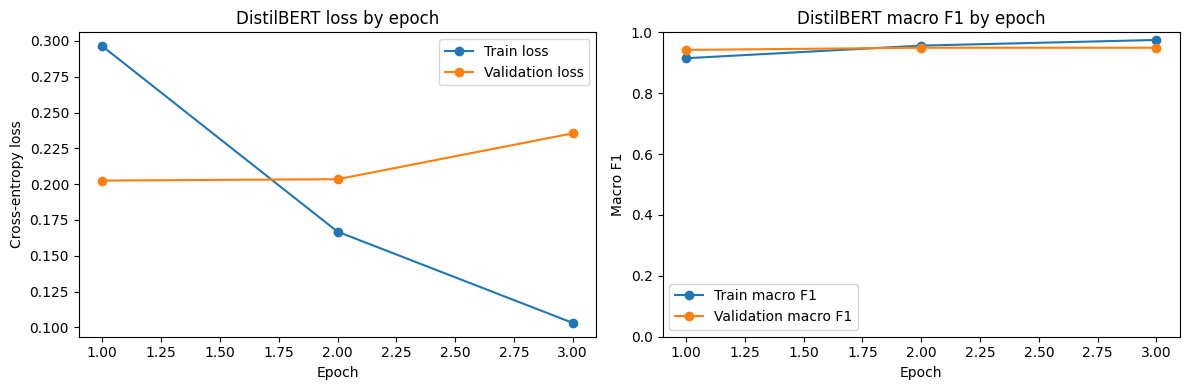

In [ ]:
# CELL 17 — Evaluate final DistilBERT and inspect learning curves.

criterion = nn.CrossEntropyLoss()

distilbert_val_metrics, val_labels, distilbert_val_pred, distilbert_val_prob = (
    evaluate_transformer(
        model=distilbert_model,
        loader=final_val_loader,
        criterion=criterion,
        description="Final validation",
    )
)

distilbert_test_metrics, test_labels, distilbert_test_pred, distilbert_test_prob = (
    evaluate_transformer(
        model=distilbert_model,
        loader=final_test_loader,
        criterion=criterion,
        description="Official test",
    )
)

classification_reports["Fine-tuned DistilBERT"] = show_classification_results(
    "Fine-tuned DistilBERT — official test",
    test_labels,
    distilbert_test_pred,
)

model_results["Fine-tuned DistilBERT"] = {
    "system_type": "Fine-tuned transformer",
    "validation": {
        key: value
        for key, value in distilbert_val_metrics.items()
        if key != "loss"
    },
    "test": {
        key: value
        for key, value in distilbert_test_metrics.items()
        if key != "loss"
    },
    "test_loss": distilbert_test_metrics["loss"],
    "best_parameters": best_transformer_params,
}
prediction_store["Fine-tuned DistilBERT"] = {
    "predictions": distilbert_test_pred,
    "probabilities": distilbert_test_prob,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    training_history["epoch"],
    training_history["train_loss"],
    marker="o",
    label="Train loss",
)
axes[0].plot(
    training_history["epoch"],
    training_history["val_loss"],
    marker="o",
    label="Validation loss",
)
axes[0].set_title("DistilBERT loss by epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

axes[1].plot(
    training_history["epoch"],
    training_history["train_f1_macro"],
    marker="o",
    label="Train macro F1",
)
axes[1].plot(
    training_history["epoch"],
    training_history["val_f1_macro"],
    marker="o",
    label="Validation macro F1",
)
axes[1].set_title("DistilBERT macro F1 by epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

,model,system_type,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Fine-tuned DistilBERT,Fine-tuned transformer,0.9434,0.9440,0.9434,0.9436,0.9436
1,TF-IDF + Logistic Regression,Baseline,0.9232,0.9231,0.9232,0.9230,0.9230
2,TF-IDF + Multinomial NB,Baseline,0.9034,0.9034,0.9034,0.9031,0.9031


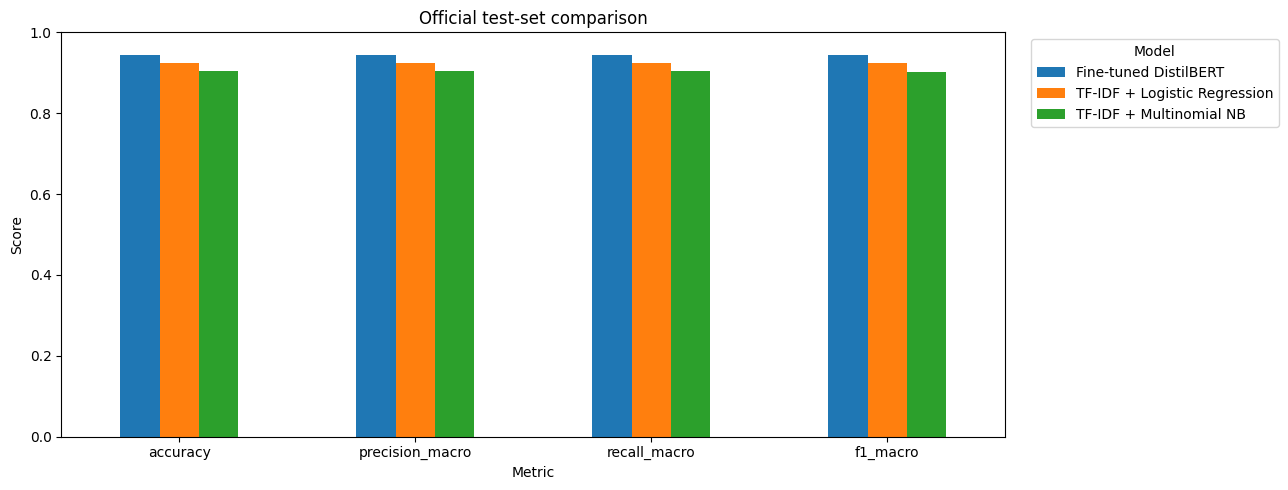

/tmp/ipykernel_3394/2243057347.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


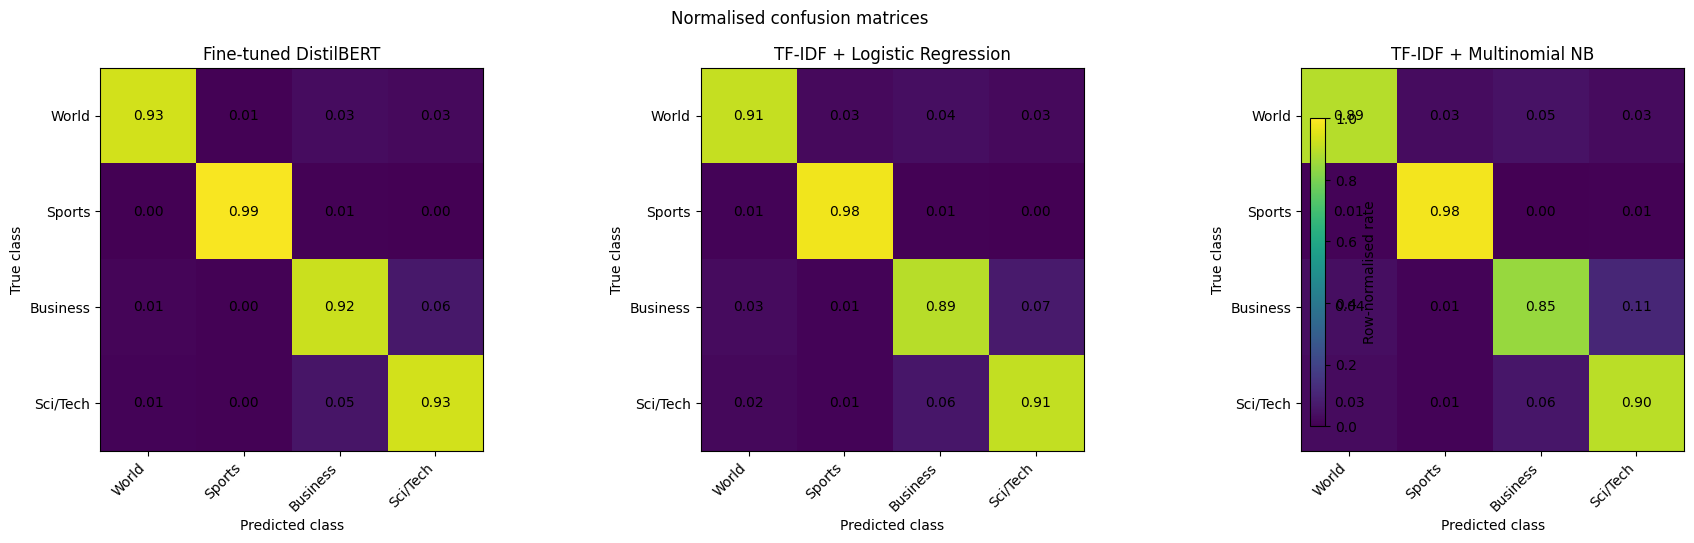

,model,class,precision,recall,f1_score,support
0,TF-IDF + Multinomial NB,World,0.9205,0.8900,0.9050,1900.0
1,TF-IDF + Multinomial NB,Sports,0.9486,0.9805,0.9643,1900.0
2,TF-IDF + Multinomial NB,Business,0.8819,0.8453,0.8632,1900.0
3,TF-IDF + Multinomial NB,Sci/Tech,0.8625,0.8979,0.8798,1900.0
4,TF-IDF + Logistic Regression,World,0.9372,0.9116,0.9242,1900.0
5,TF-IDF + Logistic Regression,Sports,0.9573,0.9795,0.9683,1900.0
6,TF-IDF + Logistic Regression,Business,0.8955,0.8932,0.8943,1900.0
7,TF-IDF + Logistic Regression,Sci/Tech,0.9022,0.9084,0.9053,1900.0
8,Fine-tuned DistilBERT,World,0.9742,0.9326,0.9529,1900.0
9,Fine-tuned DistilBERT,Sports,0.9843,0.9884,0.9863,1900.0


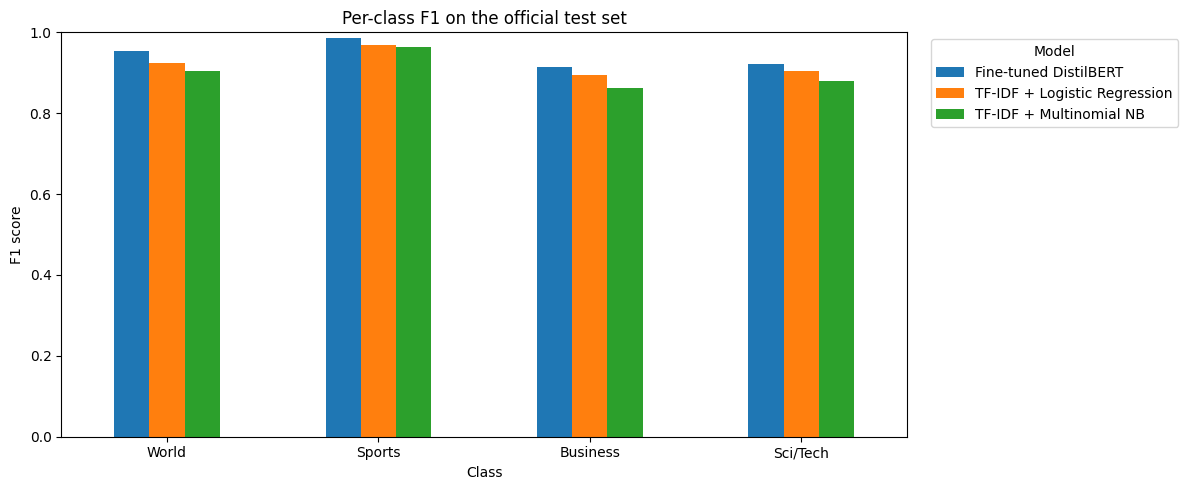

Best system by official test macro F1: Fine-tuned DistilBERT


In [ ]:
# CELL 18 — Compare all three models using identical official test examples.

comparison_rows = []
for model_name, result in model_results.items():
    comparison_rows.append(
        {
            "model": model_name,
            "system_type": result["system_type"],
            **result["test"],
        }
    )

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        by=["f1_macro", "accuracy"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(model_comparison.round(4))

metric_columns = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
]

comparison_plot_data = (
    model_comparison
    .set_index("model")[metric_columns]
    .transpose()
)

comparison_plot_data.plot(
    kind="bar",
    figsize=(13, 5),
)
plt.title("Official test-set comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, model_name in zip(axes, model_comparison["model"]):
    predictions = prediction_store[model_name]["predictions"]
    matrix = confusion_matrix(
        test_df["label"],
        predictions,
        labels=list(range(NUM_LABELS)),
        normalize="true",
    )
    image = axis.imshow(matrix, vmin=0, vmax=1)
    axis.set_title(model_name)
    axis.set_xticks(range(NUM_LABELS), CLASS_NAMES, rotation=45, ha="right")
    axis.set_yticks(range(NUM_LABELS), CLASS_NAMES)
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")

    for row in range(NUM_LABELS):
        for column in range(NUM_LABELS):
            axis.text(
                column,
                row,
                f"{matrix[row, column]:.2f}",
                ha="center",
                va="center",
            )

fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.8, label="Row-normalised rate")
plt.suptitle("Normalised confusion matrices", y=1.02)
plt.tight_layout()
plt.show()

per_class_rows = []
for model_name, report in classification_reports.items():
    for class_name in CLASS_NAMES:
        per_class_rows.append(
            {
                "model": model_name,
                "class": class_name,
                "precision": report.loc[class_name, "precision"],
                "recall": report.loc[class_name, "recall"],
                "f1_score": report.loc[class_name, "f1-score"],
                "support": report.loc[class_name, "support"],
            }
        )

per_class_metrics = pd.DataFrame(per_class_rows)
display(per_class_metrics.round(4))

per_class_pivot = per_class_metrics.pivot(
    index="class",
    columns="model",
    values="f1_score",
).reindex(CLASS_NAMES)

per_class_pivot.plot(kind="bar", figsize=(12, 5))
plt.title("Per-class F1 on the official test set")
plt.xlabel("Class")
plt.ylabel("F1 score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

best_model_name = model_comparison.loc[0, "model"]
print("Best system by official test macro F1:", best_model_name)

In [ ]:
# CELL 19 — Error analysis and reusable prediction function.
#
# High-confidence errors are particularly informative because they reveal cases
# where the model is not merely uncertain but confidently follows a misleading

error_analysis = test_df[
    ["Title", "Description", "label", "label_name"]
].copy()
error_analysis["predicted_label"] = distilbert_test_pred
error_analysis["predicted_name"] = [
    CLASS_ID_TO_NAME[int(label)]
    for label in distilbert_test_pred
]
error_analysis["confidence"] = distilbert_test_prob.max(axis=1)
error_analysis["correct"] = (
    error_analysis["label"].to_numpy()
    == error_analysis["predicted_label"].to_numpy()
)

misclassified_examples = (
    error_analysis.loc[~error_analysis["correct"]]
    .sort_values("confidence", ascending=False)
    .reset_index(drop=True)
)

print("DistilBERT misclassified test examples:", len(misclassified_examples))
display(
    misclassified_examples[
        [
            "label_name",
            "predicted_name",
            "confidence",
            "Title",
            "Description",
        ]
    ].head(20)
)

confusion_pairs = (
    misclassified_examples.groupby(
        ["label_name", "predicted_name"]
    )
    .size()
    .reset_index(name="errors")
    .sort_values("errors", ascending=False)
)
display(confusion_pairs.head(12))

@torch.no_grad()
def predict_news(title: str, description: str) -> pd.DataFrame:
    """Return predictions and probabilities from all three trained models."""
    clean_title = normalise_text(title)
    clean_description = normalise_text(description)
    combined_text = f"TITLE: {clean_title} DESCRIPTION: {clean_description}"

    rows = []

    for model_name, classical_model in [
        ("TF-IDF + Multinomial NB", nb_model),
        ("TF-IDF + Logistic Regression", lr_model),
    ]:
        probabilities = classical_model.predict_proba([combined_text])[0]
        predicted_label = int(np.argmax(probabilities))
        rows.append(
            {
                "model": model_name,
                "predicted_class": CLASS_ID_TO_NAME[predicted_label],
                "confidence": float(probabilities[predicted_label]),
            }
        )

    encoded = tokenizer(
        clean_title,
        clean_description,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    encoded = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
    }

    distilbert_model.eval()
    probabilities = torch.softmax(
        distilbert_model(**encoded).logits,
        dim=1,
    )[0].cpu().numpy()
    predicted_label = int(np.argmax(probabilities))

    rows.append(
        {
            "model": "Fine-tuned DistilBERT",
            "predicted_class": CLASS_ID_TO_NAME[predicted_label],
            "confidence": float(probabilities[predicted_label]),
        }
    )

    return pd.DataFrame(rows).sort_values(
        "confidence",
        ascending=False,
    ).reset_index(drop=True)

demo_row = test_df.sample(n=1, random_state=SEED).iloc[0]
print("Demonstration article")
print("Title:", demo_row["Title"])
print("True class:", demo_row["label_name"])
display(predict_news(demo_row["Title"], demo_row["Description"]))

DistilBERT misclassified test examples: 430


,label_name,predicted_name,confidence,Title,Description
0,Sci/Tech,Sports,0.999820,Bryant Makes First Appearance at Trial (AP),AP - NBA star Kobe Bryant arrived at his sexua...
1,World,Sports,0.999741,Ljubicic Downs Hanescu at Open De Moselle,Top-seeded Ivan Ljubicic of Croatia beat Victo...
2,Business,Sports,0.999693,Special to ESPN.com,It #39;s the age old question: quot;What do yo...
3,Sci/Tech,World,0.999652,Bush Scraps Most U.S. Sanctions on Libya (Reut...,Reuters - President Bush on Monday formally\en...
4,Business,World,0.999634,World briefs,LONDON - A man wielding a machete and a knife ...
5,Sci/Tech,Business,0.999620,Gas prices up 5 cents after Hurricane Ivan,"CAMARILLO, Calif. - Gas prices jumped more tha..."
6,World,Business,0.999552,Dow Jones Agrees to Buy MarketWatch in \$519 M...,"Dow Jones Company, the publisher of The Wall S..."
7,Sci/Tech,Business,0.999551,Before-the-Bell: GenCorp Falls 5.6 Pct. (Reuters),Reuters - Shares of GenCorp Inc. fell 5.6\perc...
8,Sports,Business,0.999542,Boston archbishop reveals anguish of closings,BOSTON Boston #39;s Archbishop is telling cath...
9,Sports,World,0.999538,"French Take Gold, Bronze in Single Kayak","ATHENS, Greece - Winning on whitewater runs in..."


,label_name,predicted_name,errors
0,Business,Sci/Tech,120
3,Sci/Tech,Business,104
9,World,Business,65
10,World,Sci/Tech,49
2,Business,World,23
5,Sci/Tech,World,17
11,World,Sports,14
6,Sports,Business,11
1,Business,Sports,8
4,Sci/Tech,Sports,8


Demonstration article
Title: Fan v Fan: Manchester City-Tottenham Hotspur
True class: Sports


,model,predicted_class,confidence
0,TF-IDF + Multinomial NB,Sports,0.999864
1,Fine-tuned DistilBERT,Sports,0.999701
2,TF-IDF + Logistic Regression,Sports,0.996259
